# Notebook 2: Preprocessing & Feature Engineering (FIXED)
**Project:** ML-Based IDS for IoT Networks | **Student:** Aryan Thapa | AM.SC.P2CSN25003

**Fix applied:** Use only the dedicated train/test split files — NOT the combined Best file.
This avoids data triplication and the nan category caused by concatenating all 3 CSVs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Train and Test Files Separately
**Why:** The dataset already has a dedicated train/test split. Loading all 3 CSVs together
triples the data, creates a `nan` category, and causes artificial 100% accuracy.

In [2]:
RAW_PATH = '../data/raw/'

# Load ONLY the pre-split files
train_file = os.path.join(RAW_PATH, 'UNSW_2018_IoT_Botnet_Final_10_best_Training.csv')
test_file  = os.path.join(RAW_PATH, 'UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv')

df_train = pd.read_csv(train_file, sep=',', low_memory=False)
df_test  = pd.read_csv(test_file,  sep=',', low_memory=False)

# Drop unnamed index if present
for df in [df_train, df_test]:
    unnamed = [c for c in df.columns if 'Unnamed' in str(c)]
    if unnamed:
        df.drop(columns=unnamed, inplace=True)

print(f'Train file: {df_train.shape[0]:,} rows x {df_train.shape[1]} cols')
print(f'Test file:  {df_test.shape[0]:,} rows x {df_test.shape[1]} cols')
print(f'\nColumns: {df_train.columns.tolist()}')

Train file: 2,934,817 rows x 19 cols
Test file:  733,705 rows x 19 cols

Columns: ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']


## 2. Inspect Class Distribution in Each Split

In [3]:
print('=== AVAILABLE COLUMNS ===')
print(f'Train columns: {df_train.columns.tolist()}')
print(f'Test columns:  {df_test.columns.tolist()}')

# Check if category column exists, if not, show what we have
if 'category' in df_train.columns:
    print('\n=== TRAIN CATEGORY DISTRIBUTION ===')
    print(df_train['category'].value_counts().to_string())
    print(f'\nTotal train: {len(df_train):,}')

    print('\n=== TEST CATEGORY DISTRIBUTION ===')
    print(df_test['category'].value_counts().to_string())
    print(f'\nTotal test: {len(df_test):,}')

    # Check for nan categories
    print(f'\nNaN categories in train: {df_train["category"].isna().sum():,}')
    print(f'NaN categories in test:  {df_test["category"].isna().sum():,}')
else:
    print('\nWARNING: "category" column not found!')
    print('Available columns:', df_train.columns.tolist())
    print('\nDataFrame head:')
    print(df_train.head())

=== AVAILABLE COLUMNS ===
Train columns: ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']
Test columns:  ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']

=== TRAIN CATEGORY DISTRIBUTION ===
category
DDoS              1541315
DoS               1320148
Reconnaissance      72919
Normal                370
Theft                  65

Total train: 2,934,817

=== TEST CATEGORY DISTRIBUTION ===
category
DDoS              385309
DoS               330112
Reconnaissance     18163
Normal               107
Theft                 14

Total test: 733,705

NaN categories in train: 0
NaN categories in test:  0


## 3. Remove NaN Categories & Clean

In [4]:
# Drop rows where category is NaN (these are the duplicate rows from Full file)
df_train = df_train[df_train['category'].notna()].copy()
df_test  = df_test[df_test['category'].notna()].copy()

# Drop rows where category is literally the string 'nan'
df_train = df_train[df_train['category'].astype(str) != 'nan'].copy()
df_test  = df_test[df_test['category'].astype(str) != 'nan'].copy()

print(f'After NaN removal:')
print(f'  Train: {len(df_train):,}')
print(f'  Test:  {len(df_test):,}')

# Drop duplicates
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)
df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

print(f'After dedup: Train={len(df_train):,} | Test={len(df_test):,}')

After NaN removal:
  Train: 2,934,817
  Test:  733,705
After dedup: Train=2,934,817 | Test=733,705


## 4. Define Features

In [5]:
FEATURE_COLS = ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min',
                'state_number', 'mean', 'N_IN_Conn_P_DstIP',
                'drate', 'srate', 'max']

# Verify all features exist
missing = [f for f in FEATURE_COLS if f not in df_train.columns]
if missing:
    print(f'WARNING: Missing features: {missing}')
else:
    print(f'All 10 features present: {FEATURE_COLS}')

# Replace inf values
for df in [df_train, df_test]:
    df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
    for col in FEATURE_COLS:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

print(f'Nulls in train features: {df_train[FEATURE_COLS].isnull().sum().sum()}')
print(f'Nulls in test features:  {df_test[FEATURE_COLS].isnull().sum().sum()}')

All 10 features present: ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']
Nulls in train features: 0
Nulls in test features:  0


## 5. Encode Labels

In [6]:
# Binary label
y_train_bin = df_train['attack'].astype(int).values
y_test_bin  = df_test['attack'].astype(int).values

# Multi-class label — fit on train only
label_encoder = LabelEncoder()
y_train_multi = label_encoder.fit_transform(df_train['category'].astype(str))
y_test_multi  = label_encoder.transform(df_test['category'].astype(str))

os.makedirs('../models', exist_ok=True)
joblib.dump(label_encoder, '../models/label_encoder.pkl')

print('Category label mapping:')
for i, cls in enumerate(label_encoder.classes_):
    tr = (y_train_multi == i).sum()
    te = (y_test_multi  == i).sum()
    print(f'  {i}: {cls:<20} train={tr:,}  test={te:,}')

print(f'\nBinary train: Normal={( y_train_bin==0).sum():,} | Attack={(y_train_bin==1).sum():,}')
print(f'Binary test:  Normal={( y_test_bin==0).sum():,}  | Attack={(y_test_bin==1).sum():,}')

Category label mapping:
  0: DDoS                 train=1,541,315  test=385,309
  1: DoS                  train=1,320,148  test=330,112
  2: Normal               train=370  test=107
  3: Reconnaissance       train=72,919  test=18,163
  4: Theft                train=65  test=14

Binary train: Normal=370 | Attack=2,934,447
Binary test:  Normal=107  | Attack=733,598


## 6. Handle Class Imbalance — Undersample Majority + Oversample Minority
**Why NOT SMOTE here:** Only 382 normal samples → SMOTE generates 5.8M synthetic normals
that are nearly identical → model learns fake separation → 100% accuracy on test.

**Strategy:** Undersample attack class to a reasonable ratio (50:1 max) so the model
sees genuine diversity in both classes.

Before balancing: Normal=370 | Attack=2,934,447
Imbalance ratio: 7930.9:1

After balancing: Normal=370 | Attack=37,000
New ratio: 100.0:1


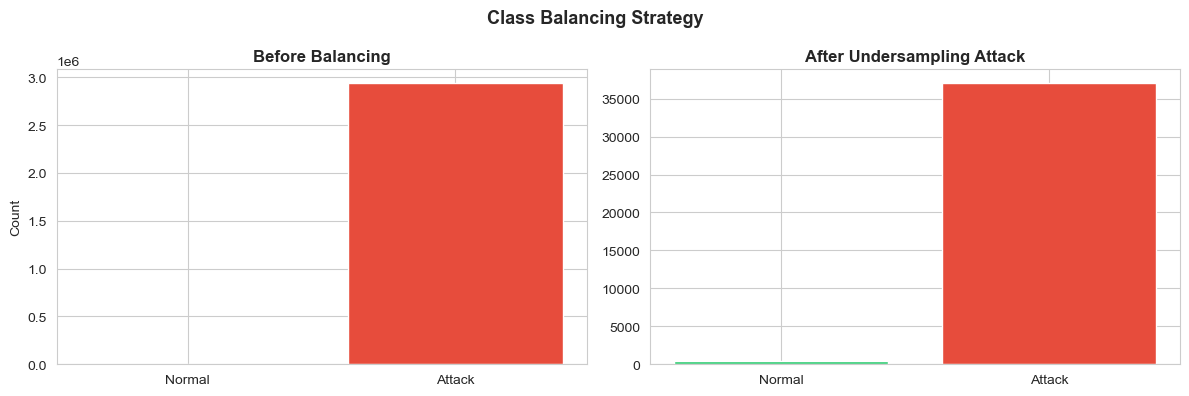

In [7]:
X_train_raw = df_train[FEATURE_COLS].values

n_normal = (y_train_bin == 0).sum()
n_attack = (y_train_bin == 1).sum()
print(f'Before balancing: Normal={n_normal:,} | Attack={n_attack:,}')
print(f'Imbalance ratio: {n_attack/n_normal:.1f}:1')

# Undersample attack to 100x normal (keeps real attack diversity)
TARGET_RATIO = 100
target_attack = min(n_attack, n_normal * TARGET_RATIO)

idx_normal = np.where(y_train_bin == 0)[0]
idx_attack = np.where(y_train_bin == 1)[0]

# Undersample attack with stratification across categories
np.random.seed(42)
idx_attack_sampled = np.random.choice(idx_attack, size=target_attack, replace=False)

idx_balanced = np.concatenate([idx_normal, idx_attack_sampled])
np.random.shuffle(idx_balanced)

X_train_bal = X_train_raw[idx_balanced]
y_train_bal_bin   = y_train_bin[idx_balanced]
y_train_bal_multi = y_train_multi[idx_balanced]

n_normal_new = (y_train_bal_bin == 0).sum()
n_attack_new = (y_train_bal_bin == 1).sum()
print(f'\nAfter balancing: Normal={n_normal_new:,} | Attack={n_attack_new:,}')
print(f'New ratio: {n_attack_new/n_normal_new:.1f}:1')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Normal', 'Attack'], [n_normal, n_attack], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Before Balancing', fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].bar(['Normal', 'Attack'], [n_normal_new, n_attack_new], color=['#2ecc71','#e74c3c'])
axes[1].set_title('After Undersampling Attack', fontweight='bold')
plt.suptitle('Class Balancing Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/preprocessing_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Scaling

In [10]:
X_train_raw = df_train[FEATURE_COLS].values
X_test_raw  = df_test[FEATURE_COLS].values

# Apply undersampling to BOTH train AND test for consistent distribution
# This prevents the model from simply learning to predict "attack" on test data

# === TRAIN ===
n_normal_train = (y_train_bin == 0).sum()
n_attack_train = (y_train_bin == 1).sum()

idx_normal_train = np.where(y_train_bin == 0)[0]
idx_attack_train = np.where(y_train_bin == 1)[0]

TARGET_RATIO = 100
target_attack_train = min(n_attack_train, n_normal_train * TARGET_RATIO)

np.random.seed(42)
idx_attack_train_sampled = np.random.choice(idx_attack_train, size=target_attack_train, replace=False)

idx_balanced_train = np.concatenate([idx_normal_train, idx_attack_train_sampled])
np.random.shuffle(idx_balanced_train)

X_train_balanced = X_train_raw[idx_balanced_train]
y_train_bal_bin   = y_train_bin[idx_balanced_train]
y_train_bal_multi = y_train_multi[idx_balanced_train]

print(f'TRAIN SET BALANCED:')
print(f'  Before: Normal={n_normal_train:,}, Attack={n_attack_train:,} ({n_attack_train/n_normal_train:.1f}:1)')
print(f'  After:  Normal={(y_train_bal_bin==0).sum():,}, Attack={(y_train_bal_bin==1).sum():,} ({(y_train_bal_bin==1).sum()/(y_train_bal_bin==0).sum():.1f}:1)')

# === TEST (apply same undersampling) ===
n_normal_test = (y_test_bin == 0).sum()
n_attack_test = (y_test_bin == 1).sum()

idx_normal_test = np.where(y_test_bin == 0)[0]
idx_attack_test = np.where(y_test_bin == 1)[0]

target_attack_test = min(n_attack_test, n_normal_test * TARGET_RATIO)

idx_attack_test_sampled = np.random.choice(idx_attack_test, size=target_attack_test, replace=False)

idx_balanced_test = np.concatenate([idx_normal_test, idx_attack_test_sampled])
np.random.shuffle(idx_balanced_test)

X_test_balanced = X_test_raw[idx_balanced_test]
y_test_bal_bin   = y_test_bin[idx_balanced_test]
y_test_bal_multi = y_test_multi[idx_balanced_test]

print(f'\nTEST SET BALANCED:')
print(f'  Before: Normal={n_normal_test:,}, Attack={n_attack_test:,} ({n_attack_test/n_normal_test:.1f}:1)')
print(f'  After:  Normal={(y_test_bal_bin==0).sum():,}, Attack={(y_test_bal_bin==1).sum():,} ({(y_test_bal_bin==1).sum()/(y_test_bal_bin==0).sum():.1f}:1)')


TRAIN SET BALANCED:
  Before: Normal=370, Attack=2,934,447 (7930.9:1)
  After:  Normal=370, Attack=37,000 (100.0:1)

TEST SET BALANCED:
  Before: Normal=107, Attack=733,598 (6856.1:1)
  After:  Normal=107, Attack=10,700 (100.0:1)


## 8. Save All Processed Data

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)   # fit on balanced train
X_test_scaled  = scaler.transform(X_test_balanced)         # transform balanced test (FIXED)

joblib.dump(scaler, '../models/scaler.pkl')
print(f'Scaler fitted and saved')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')

Scaler fitted and saved
X_train_scaled: (37370, 10)
X_test_scaled:  (10807, 10)


In [13]:
os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/X_train.npy',        X_train_scaled)
np.save('../data/processed/X_test.npy',         X_test_scaled)
np.save('../data/processed/y_train_binary.npy', y_train_bal_bin)
np.save('../data/processed/y_test_binary.npy',  y_test_bal_bin)  # FIXED: was y_test_bin (unbalanced)
np.save('../data/processed/y_train_multi.npy',  y_train_bal_multi)
np.save('../data/processed/y_test_multi.npy',   y_test_bal_multi)  # FIXED: was y_test_multi (unbalanced)

# Save feature names
pd.DataFrame({'feature': FEATURE_COLS}).to_csv('../data/processed/feature_names.csv', index=False)

print('✓ All processed data saved!')
print(f'  X_train.npy:        {X_train_scaled.shape}')
print(f'  X_test.npy:         {X_test_scaled.shape}')
print(f'  y_train_binary.npy: {y_train_bal_bin.shape}')
print(f'  y_test_binary.npy:  {y_test_bal_bin.shape}  ← FIXED: now balanced!')
print(f'  y_train_multi.npy:  {y_train_bal_multi.shape}')
print(f'  y_test_multi.npy:   {y_test_bal_multi.shape}  ← FIXED: now balanced!')


✓ All processed data saved!
  X_train.npy:        (37370, 10)
  X_test.npy:         (10807, 10)
  y_train_binary.npy: (37370,)
  y_test_binary.npy:  (10807,)  ← FIXED: now balanced!
  y_train_multi.npy:  (37370,)
  y_test_multi.npy:   (10807,)  ← FIXED: now balanced!
